In [30]:
import pandas as pd
import seaborn as sns
df = pd.read_csv(r"..\..\dataset\dataset_module_one_DM2.csv")

In [31]:
df = df[df['CGAS-CGAS_Score'] < 100]

## Classifica Features per importanza

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# Block 1: Data Setup
# ==========================================

# Separate independent features (X) and the dependent target (y)
# X = df.drop(columns=['CGAS-CGAS_Score'])
# y = df['CGAS-CGAS_Score']
X = df.drop(columns=['SDS-SDS_Total_T'])
y = df['SDS-SDS_Total_T']

# Standard split into Train and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Block 2: Models and RFE Setup
# ==========================================

# Initialize non-linear regression models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Theoretical Explanation of RFE:
# RFE (Recursive Feature Elimination) works by training the base estimator, 
# obtaining the feature importances (or coefficients), and recursively eliminating 
# the least important feature(s). This process repeats until the desired number 
# of features remains. By setting n_features_to_select=1, RFE will eliminate 
# features down to the last one, effectively ranking all features from most to least important.
rfe_rf = RFE(estimator=rf_model, n_features_to_select=1)
rfe_xgb = RFE(estimator=xgb_model, n_features_to_select=1)

# ==========================================
# Block 3: Fit & Ranking Extraction
# ==========================================

# Train the RFE instances on the training data
rfe_rf.fit(X_train, y_train)
rfe_xgb.fit(X_train, y_train)

# Extract the feature ranking attributes (1 means most important)
ranking_rf = rfe_rf.ranking_
ranking_xgb = rfe_xgb.ranking_

# Create a DataFrame to compare the feature rankings
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Ranking': ranking_rf,
    'XGBoost_Ranking': ranking_xgb
})

# Sort by Random Forest ranking for clearer visualization of importance
ranking_df_sorted = ranking_df.sort_values(by='RF_Ranking').reset_index(drop=True)

print("--- Feature Ranking Comparison ---")
print(ranking_df_sorted.to_string())
print("\n")

# ==========================================
# Block 4: Evaluation (MSE and R2)
# ==========================================

# Predict on the Test Set using the trained RFE models
# Note: RFE uses the underlying estimator trained on the selected features
preds_rf = rfe_rf.predict(X_test)
preds_xgb = rfe_xgb.predict(X_test)

# Calculate Mean Squared Error (distance of predicted values)
mse_rf = mean_squared_error(y_test, preds_rf)
mse_xgb = mean_squared_error(y_test, preds_xgb)

# Calculate R-squared (explained variance)
r2_rf = r2_score(y_test, preds_rf)
r2_xgb = r2_score(y_test, preds_xgb)

print("--- Model Evaluation on Test Set ---")
print(f"Random Forest (RFE) -> MSE: {mse_rf:.4f} | R^2: {r2_rf:.4f}")
print(f"XGBoost (RFE)       -> MSE: {mse_xgb:.4f} | R^2: {r2_xgb:.4f}")

--- Feature Ranking Comparison ---
                                   Feature  RF_Ranking  XGBoost_Ranking
0                   Body_Mass_Index_Global           1                5
1                          Body_Proportion           2                2
2                              BIA-BIA_BMI           3               21
3                   Fitness_Endurance-Time           4                4
4                   Mean_Arterial_Pressure           5                3
5                              BIA-BIA_DEE           6               19
6                              BIA-BIA_FMI           7               15
7                              BIA-BIA_BMC           8               22
8                       Physical-HeartRate           9               25
9                              BIA-BIA_ICW          10               13
10                         CGAS-CGAS_Score          11               26
11                       PAQ_C-PAQ_C_Total          12                6
12                           

## Processo iterativo per determinare le migliori features indipendenti

Fitting RFECV for Random Forest...
Fitting RFECV for XGBoost...
Optimal number of features (Random Forest): 19
Optimal number of features (XGBoost): 1


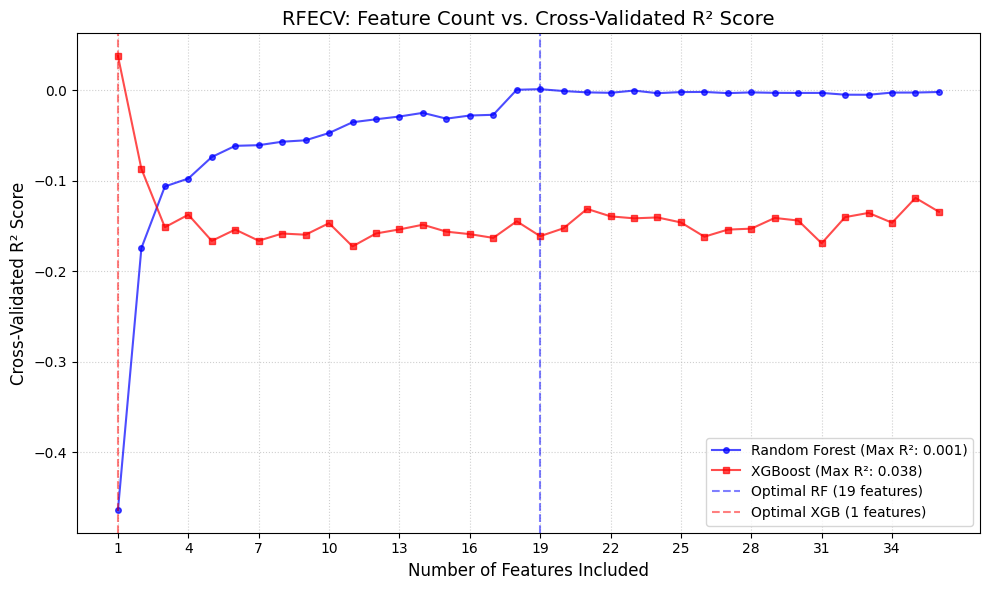


--- Final Evaluation on Unseen Test Set (Optimal Features) ---
Random Forest -> MSE: 90.4679 | R²: 0.0085
XGBoost       -> MSE: 86.6588 | R²: 0.0502
Selected Features by Random Forest: ['CGAS-CGAS_Score', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total', 'sii', 'Body_Mass_Index_Global', 'Body_Proportion', 'Fitness_Endurance-Time', 'Mean_Arterial_Pressure']


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# Block 1: Data Setup & Cross-Validation
# ==========================================

# Assuming 'df' is already loaded and contains the target 'CGAS-CGAS_Score'
X = df.drop(columns=['SDS-SDS_Total_T'])
y = df['SDS-SDS_Total_T']

# Split data into Train and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Cross-Validation strategy
# Using 5-fold CV to ensure robust evaluation during the RFE process
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# Block 2: RFECV Initialization
# ==========================================

# Initialize the base non-linear estimators
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Initialize RFECV for both models
# step=1: removes 1 feature at a time
# scoring='r2': uses R-squared to evaluate the model performance at each step
# min_features_to_select=1: forces the algorithm to explore all the way down to 1 feature
rfecv_rf = RFECV(estimator=rf_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1)
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1)

# ==========================================
# Block 3: Model Fitting
# ==========================================

# Fit RFECV. This automatically searches for the optimal number of features
# by calculating the R2 score across the 5 folds for every subset of features.
print("Fitting RFECV for Random Forest...")
rfecv_rf.fit(X_train, y_train)

print("Fitting RFECV for XGBoost...")
rfecv_xgb.fit(X_train, y_train)

# ==========================================
# Block 4: Extracting Results & Plotting the "Performance Curve"
# ==========================================

# The optimal number of features found mathematically by the algorithm
optimal_features_rf = rfecv_rf.n_features_
optimal_features_xgb = rfecv_xgb.n_features_

print(f"Optimal number of features (Random Forest): {optimal_features_rf}")
print(f"Optimal number of features (XGBoost): {optimal_features_xgb}")

# Extract the cross-validation scores (mean R2 across the folds for each number of features)
# The length of 'mean_test_score' corresponds to the number of evaluated feature subsets
scores_rf = rfecv_rf.cv_results_['mean_test_score']
scores_xgb = rfecv_xgb.cv_results_['mean_test_score']

# Create the X-axis (Number of Features)
num_features_evaluated = len(scores_rf)
x_axis = range(1, num_features_evaluated + 1)

# Plotting the Performance Curve to visually inspect the "elbow"
plt.figure(figsize=(10, 6))

plt.plot(x_axis, scores_rf, label=f'Random Forest (Max R²: {max(scores_rf):.3f})', 
         color='blue', marker='o', markersize=4, alpha=0.7)
plt.plot(x_axis, scores_xgb, label=f'XGBoost (Max R²: {max(scores_xgb):.3f})', 
         color='red', marker='s', markersize=4, alpha=0.7)

# Highlight the optimal points (the "peaks" automatically selected by RFECV)
plt.axvline(x=optimal_features_rf, color='blue', linestyle='--', alpha=0.5, 
            label=f'Optimal RF ({optimal_features_rf} features)')
plt.axvline(x=optimal_features_xgb, color='red', linestyle='--', alpha=0.5, 
            label=f'Optimal XGB ({optimal_features_xgb} features)')

plt.title('RFECV: Feature Count vs. Cross-Validated R² Score', fontsize=14)
plt.xlabel('Number of Features Included', fontsize=12)
plt.ylabel('Cross-Validated R² Score', fontsize=12)
plt.xticks(range(1, num_features_evaluated + 1, max(1, num_features_evaluated // 10)))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

# Display the curve. This helps you decide if you want to override the 
# algorithm's choice (e.g., picking 5 features if the curve flattens there).
plt.show()

# ==========================================
# Block 5: Final Evaluation on Unseen Data
# ==========================================

# RFECV automatically acts as an estimator configured with the optimal features.
# Calling predict() will automatically transform X_test to use only the selected subset.
preds_rf_opt = rfecv_rf.predict(X_test)
preds_xgb_opt = rfecv_xgb.predict(X_test)

print("\n--- Final Evaluation on Unseen Test Set (Optimal Features) ---")
print(f"Random Forest -> MSE: {mean_squared_error(y_test, preds_rf_opt):.4f} | R²: {r2_score(y_test, preds_rf_opt):.4f}")
print(f"XGBoost       -> MSE: {mean_squared_error(y_test, preds_xgb_opt):.4f} | R²: {r2_score(y_test, preds_xgb_opt):.4f}")

# Optional: Print the names of the selected features for the best model
# Example for Random Forest:
selected_features_rf = X.columns[rfecv_rf.support_]
print("Selected Features by Random Forest:", list(selected_features_rf))

In [ ]:
sns.histplot(df["CGAS-CGAS_Score"])

In [ ]:
(df["CGAS-CGAS_Score"] > 100).sum()

In [ ]:
sns.histplot(df[df["CGAS-CGAS_Score"] < 100]["CGAS-CGAS_Score"])

In [ ]:
df[df["CGAS-CGAS_Score"] < 100]["CGAS-CGAS_Score"].describe()

In [ ]:
df[df["CGAS-CGAS_Score"] == 65]["CGAS-CGAS_Score"].value_counts()

<Axes: xlabel='SDS-SDS_Total_T', ylabel='Count'>

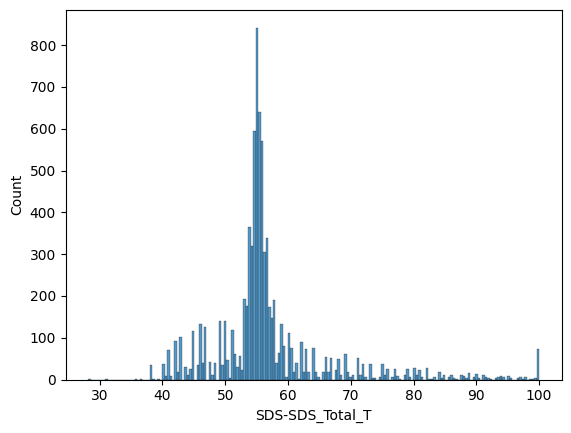

In [34]:
sns.histplot(df["SDS-SDS_Total_T"])